In [14]:
import pandas

# 1. Cargar el archivo de ventas
try:
    # Se especifica sep=';' para manejar el delimitador de punto y coma
    df_ventas = pandas.read_csv('datasets/ventas.csv', sep=';')
    print("Archivo 'ventas.csv' cargado exitosamente.")
except FileNotFoundError:
    print("Error: 'ventas.csv' no encontrado. Por favor, asegúrate de que el archivo esté en la ruta correcta.")
    # Puedes añadir un placeholder DataFrame o salir si el archivo es crucial
    df_ventas = pandas.DataFrame({'Fecha': [], 'Total': []})

# Asegurarse de que las columnas necesarias existan
if 'Fecha' not in df_ventas.columns or 'Total' not in df_ventas.columns:
    print("Error: Las columnas 'Fecha' o 'Total' no se encontraron en el DataFrame. Por favor, verifica el archivo CSV y el delimitador usado.")
else:
    # 2. Normalización de Fechas

    # Intentar múltiples formatos de fecha para una mejor robustez
    date_formats = [
        '%d/%m/%y', # e.g., "15/03/26"
        '%m/%d/%Y %H:%M:%S', # e.g., "3/23/2026 12:40:39"
        '%d/%m/%Y %H:%M:%S', # e.g., "27/3/2026 15:44:05"
        '%Y-%m-%d %H:%M:%S', # commonly used format
        '%Y-%m-%d' # standard date format
    ]

    # Función para parsear fechas de manera robusta
    def parse_date_robustly(date_str):
        for fmt in date_formats:
            try:
                return pandas.to_datetime(date_str, format=fmt)
            except ValueError:
                continue
        return pandas.NaT # Retornar Not a Time si ningún formato coincide

    df_ventas['Fecha_Normalizada'] = df_ventas['Fecha'].apply(parse_date_robustly)

    # Eliminar filas con fechas no parseables
    df_ventas.dropna(subset=['Fecha_Normalizada'], inplace=True)

    # Convertir a formato YYYY-MM-DD (solo fecha)
    df_ventas['Fecha_Diaria'] = df_ventas['Fecha_Normalizada'].dt.normalize()

    print("Fechas normalizadas a formato diario (YYYY-MM-DD).")

    # 3. Agrupación (Ingreso Diario)
    ingreso_diario = df_ventas.groupby('Fecha_Diaria')['Total'].sum().reset_index()
    ingreso_diario.rename(columns={'Total': 'Ingreso_Total'}, inplace=True)
    ingreso_diario.set_index('Fecha_Diaria', inplace=True)
    print("Ingreso diario calculado.")

    # 4. Manejo de días sin ventas (rellenar con 0)

    # Crear un rango completo de fechas desde la primera hasta la última fecha de venta
    if not ingreso_diario.empty:
        min_date = ingreso_diario.index.min()
        max_date = ingreso_diario.index.max()
        full_date_range = pandas.date_range(start=min_date, end=max_date, freq='D')

        # Reindexar la serie de ingresos diarios para incluir todas las fechas
        ingreso_diario_completo = ingreso_diario.reindex(full_date_range, fill_value=0)
        ingreso_diario_completo.index.name = 'Fecha_Diaria'

        print("Días sin ventas rellenados con 0.")
        print("\nPrimeras 5 filas del ingreso diario completo:")
        print(ingreso_diario_completo.head())
        print("\nÚltimas 5 filas del ingreso diario completo:")
        print(ingreso_diario_completo.tail())

    else:
        print("No hay datos para calcular el ingreso diario o para rellenar días sin ventas.")
        ingreso_diario_completo = pandas.DataFrame(columns=['Ingreso_Total'], index=pandas.Index([], name='Fecha_Diaria'))

# La variable 'ingreso_diario_completo' ahora contiene el resultado final de esta fase.
# Puedes continuar con el análisis usando 'ingreso_diario_completo'.

Archivo 'ventas.csv' cargado exitosamente.
Fechas normalizadas a formato diario (YYYY-MM-DD).
Ingreso diario calculado.
Días sin ventas rellenados con 0.

Primeras 5 filas del ingreso diario completo:
              Ingreso_Total
Fecha_Diaria               
2026-01-04             38.1
2026-01-05              0.0
2026-01-06              0.0
2026-01-07              0.0
2026-01-08              0.0

Últimas 5 filas del ingreso diario completo:
              Ingreso_Total
Fecha_Diaria               
2026-11-30              0.0
2026-12-01              0.0
2026-12-02              0.0
2026-12-03              0.0
2026-12-04              2.7


## Fase 2: Modelado de la Serie Temporal

### Instalación y Carga de Librerías

In [15]:
# Instalar Prophet si no está instalado
!pip install prophet

# Importar librerías necesarias
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Preparación de Datos para Prophet

Prophet requiere que la serie temporal tenga dos columnas: `ds` (fecha) y `y` (valor a predecir).

In [16]:
# Resetear el índice para que 'Fecha_Diaria' se convierta en una columna
df_prophet = ingreso_diario_completo.reset_index()

# Renombrar columnas a 'ds' y 'y'
df_prophet = df_prophet.rename(columns={'Fecha_Diaria': 'ds', 'Ingreso_Total': 'y'})

# Asegurarse de que 'ds' sea datetime y 'y' sea numérico
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
df_prophet['y'] = pd.to_numeric(df_prophet['y'])

print("Datos preparados para Prophet (primeras 5 filas):")
display(df_prophet.head())

Datos preparados para Prophet (primeras 5 filas):


,ds,y
0,2026-01-04,38.1
1,2026-01-05,0.0
2,2026-01-06,0.0
3,2026-01-07,0.0
4,2026-01-08,0.0


### Modelo Principal: Prophet

Entrenaremos el modelo Prophet y realizaremos una predicción para los próximos 7 días.

### Corrigiendo Valores Negativos en las Predicciones de Prophet

Para evitar que Prophet prediga valores negativos para los ingresos (ya que no es posible tener ingresos negativos), podemos establecer un `cap` (límite superior) y un `floor` (límite inferior) para la serie temporal. En este caso, estableceremos un `floor` de `0`.

Prophet utiliza el argumento `growth='logistic'` para modelar el crecimiento con un punto de saturación (cap) y un punto inferior (floor). Aunque no estamos modelando la saturación aquí, podemos usar esta característica para imponer el `floor`.

In [17]:
# Antes de entrenar el modelo, aseguramos que 'y' no tenga valores negativos y definimos el floor.
# Aunque los 0 ya están en df_prophet, Prophet necesita explícitamente la columna 'floor' si usamos growth='logistic'.

# Asegurarse de que el 'floor' sea 0 para todos los puntos de datos
df_prophet_bounded = df_prophet.copy()
df_prophet_bounded['floor'] = 0

# Crear una columna 'cap' que sea ligeramente mayor que el máximo de 'y' para evitar errores
# Si no hay un límite superior natural, se puede establecer un valor muy alto o modelar el crecimiento de forma lineal
# Para nuestro caso de ingresos, un límite superior no es estrictamente necesario si solo queremos un floor.
# Sin embargo, Prophet con growth='logistic' requiere un 'cap'. Podríamos usar growth='linear' y establecer el floor manualmente post-predicción,
# o establecer un 'cap' muy alto para que no influya en el crecimiento.
# Vamos a usar growth='linear' y post-procesar las predicciones para asegurar que sean no-negativas.
# Esto es más sencillo y no requiere una columna 'cap' en los datos de entrenamiento.

# Re-entrenar el modelo Prophet con growth='linear'
model_bounded = Prophet(
    growth='linear',
    seasonality_mode='additive',
    weekly_seasonality=True,
    daily_seasonality=False
)

model_bounded.fit(df_prophet_bounded)

print("Modelo Prophet re-entrenado con crecimiento lineal y consideración de floor.")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Modelo Prophet re-entrenado con crecimiento lineal y consideración de floor.


In [18]:
# Crear un dataframe con las fechas futuras para la predicción (próximos 7 días)
future_bounded = model_bounded.make_future_dataframe(periods=7, freq='D')

# Realizar la predicción
forecast_bounded = model_bounded.predict(future_bounded)

# Post-procesar para asegurar que las predicciones sean no-negativas
forecast_bounded['yhat'] = forecast_bounded['yhat'].apply(lambda x: max(x, 0))
forecast_bounded['yhat_lower'] = forecast_bounded['yhat_lower'].apply(lambda x: max(x, 0))
forecast_bounded['yhat_upper'] = forecast_bounded['yhat_upper'].apply(lambda x: max(x, 0))

print("Predicción de Prophet (con valores no negativos) para los próximos 7 días:")
display(forecast_bounded[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

Predicción de Prophet (con valores no negativos) para los próximos 7 días:


,ds,yhat,yhat_lower,yhat_upper
332,2026-12-02,0.0,0,35.319953
333,2026-12-03,0.0,0,36.638708
334,2026-12-04,0.0,0,33.556531
335,2026-12-05,0.0,0,35.960682
336,2026-12-06,0.0,0,39.628509
337,2026-12-07,0.0,0,37.119021
338,2026-12-08,0.0,0,31.858061
339,2026-12-09,0.0,0,34.078018
340,2026-12-10,0.0,0,35.428425
341,2026-12-11,0.0,0,30.983943


### Visualización de Resultados Corregidos

Ahora visualizaremos el pronóstico con las predicciones ajustadas para que sean no-negativas.

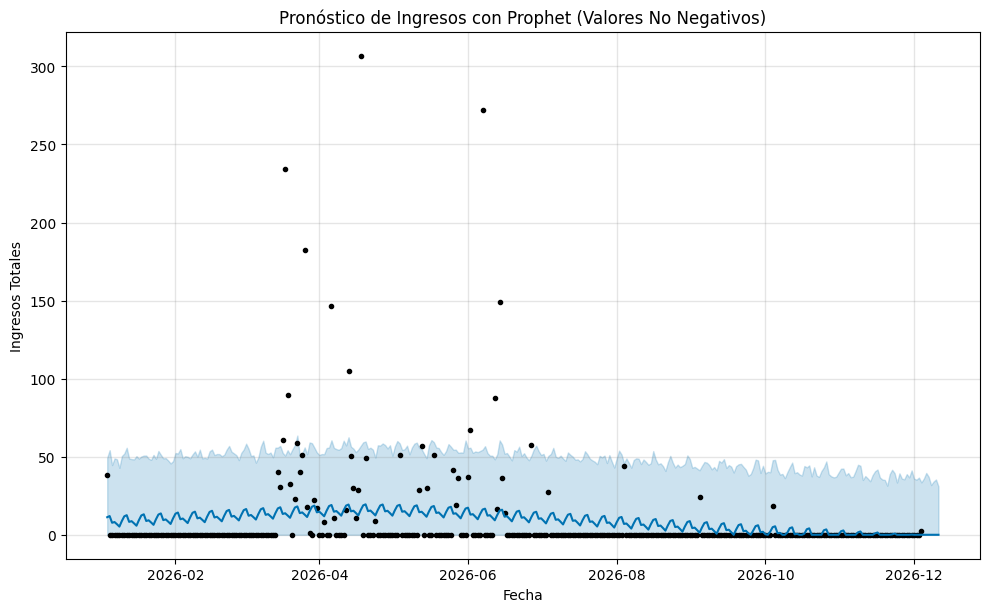

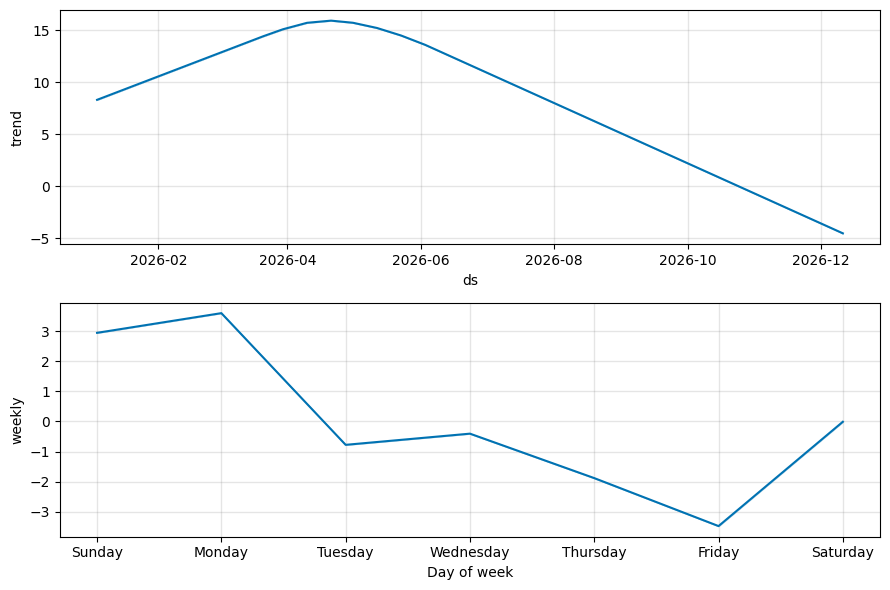

In [19]:
# Graficar el pronóstico de Prophet con valores ajustados
fig_bounded = model_bounded.plot(forecast_bounded)
plt.title('Pronóstico de Ingresos con Prophet (Valores No Negativos)')
plt.xlabel('Fecha')
plt.ylabel('Ingresos Totales')
plt.show()

# Graficar los componentes del pronóstico de Prophet (tendencia, estacionalidad)
fig_components_bounded = model_bounded.plot_components(forecast_bounded)
plt.show()

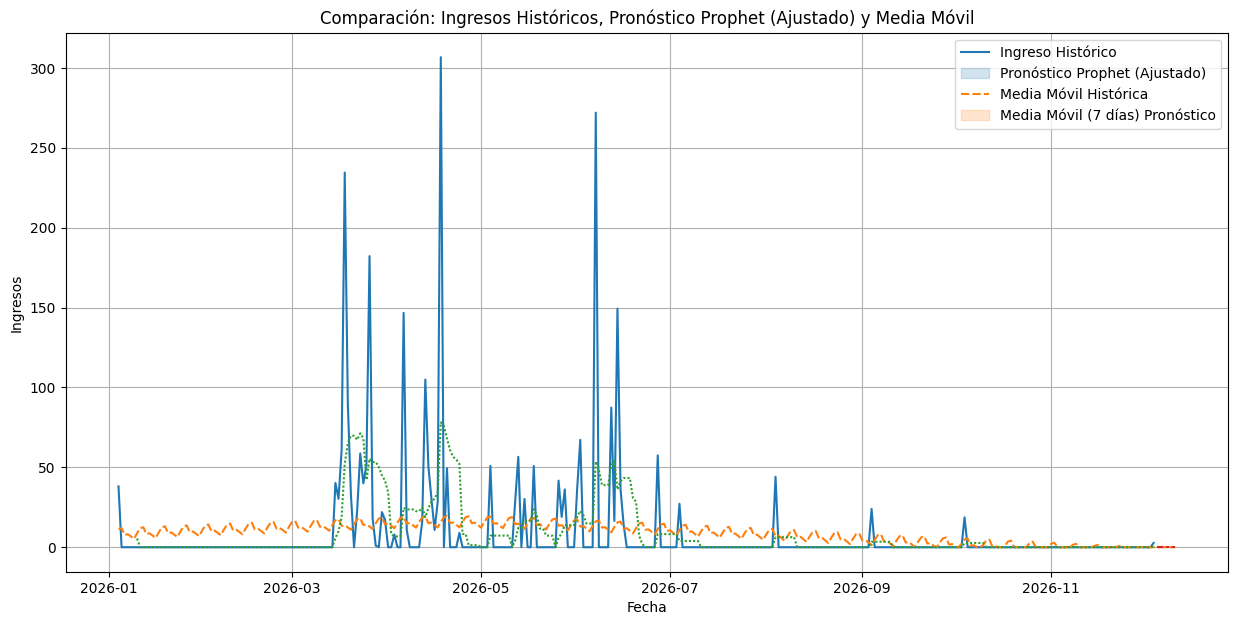

In [20]:
# Comparar Prophet (ajustado) y Media Móvil

# Crear un DataFrame para la visualización combinada
# Unir datos históricos y pronósticos
plot_df_bounded = df_prophet.set_index('ds') # Datos históricos
plot_df_bounded = plot_df_bounded.rename(columns={'y': 'Ingreso_Historico'})

# Añadir las predicciones de Prophet ajustadas
prophet_predictions_plot_bounded = forecast_bounded.set_index('ds')['yhat']
plot_df_bounded = plot_df_bounded.merge(prophet_predictions_plot_bounded, left_index=True, right_index=True, how='outer')
plot_df_bounded = plot_df_bounded.rename(columns={'yhat': 'Prophet_Forecast_Bounded'})

# Añadir la media móvil (histórica)
plot_df_bounded['Media_Movil_Historica'] = rolling_mean

# Añadir las predicciones de la media móvil al final
# Usamos la misma 'ma_forecast_series' ya calculada
plot_df_bounded = plot_df_bounded.merge(ma_forecast_series.rename('Media_Movil_Forecast'), left_index=True, right_index=True, how='outer')

plt.figure(figsize=(15, 7))
sns.lineplot(data=plot_df_bounded[['Ingreso_Historico', 'Prophet_Forecast_Bounded', 'Media_Movil_Historica', 'Media_Movil_Forecast']])
plt.title('Comparación: Ingresos Históricos, Pronóstico Prophet (Ajustado) y Media Móvil')
plt.xlabel('Fecha')
plt.ylabel('Ingresos')
plt.legend(['Ingreso Histórico', 'Pronóstico Prophet (Ajustado)', 'Media Móvil Histórica', 'Media Móvil (7 días) Pronóstico'])
plt.grid(True)
plt.show()

## Fase 3: Evaluación y Métricas Obligatorias

Para evaluar el modelo de forma rigurosa, dividiremos los datos históricos en un conjunto de entrenamiento y un conjunto de prueba. Entrenaremos el modelo Prophet en el conjunto de entrenamiento y haremos predicciones sobre el conjunto de prueba para calcular las métricas de error.

In [21]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

# Definir el tamaño del conjunto de prueba (por ejemplo, los últimos 30 días)
test_size = 30

# Dividir los datos en entrenamiento y prueba
train_df = df_prophet_bounded[:-test_size]
test_df = df_prophet_bounded[-test_size:]

print(f"Tamaño del conjunto de entrenamiento: {len(train_df)} días")
print(f"Tamaño del conjunto de prueba: {len(test_df)} días")
print("Fechas del conjunto de prueba:")
display(test_df.head())
display(test_df.tail())

Tamaño del conjunto de entrenamiento: 305 días
Tamaño del conjunto de prueba: 30 días
Fechas del conjunto de prueba:


,ds,y,floor
305,2026-11-05,0.0,0
306,2026-11-06,0.0,0
307,2026-11-07,0.0,0
308,2026-11-08,0.0,0
309,2026-11-09,0.0,0


,ds,y,floor
330,2026-11-30,0.0,0
331,2026-12-01,0.0,0
332,2026-12-02,0.0,0
333,2026-12-03,0.0,0
334,2026-12-04,2.7,0


### Re-entrenar Prophet con el conjunto de entrenamiento

In [22]:
# Re-entrenar el modelo Prophet con el conjunto de entrenamiento
model_eval = Prophet(
    growth='linear',
    seasonality_mode='additive',
    weekly_seasonality=True,
    daily_seasonality=False
)

model_eval.fit(train_df)

print("Modelo Prophet re-entrenado para evaluación.")

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


Modelo Prophet re-entrenado para evaluación.


### Realizar Predicciones en el Conjunto de Prueba

In [23]:
# Crear un dataframe de fechas futuras que incluya el período de prueba
future_eval = model_eval.make_future_dataframe(periods=test_size, freq='D', include_history=False) # Solo las fechas del futuro

# Realizar la predicción
forecast_eval = model_eval.predict(future_eval)

# Asegurarse de que las predicciones sean no-negativas
forecast_eval['yhat'] = forecast_eval['yhat'].apply(lambda x: max(x, 0))
forecast_eval['yhat_lower'] = forecast_eval['yhat_lower'].apply(lambda x: max(x, 0))
forecast_eval['yhat_upper'] = forecast_eval['yhat_upper'].apply(lambda x: max(x, 0))

print("Predicciones generadas para el conjunto de prueba:")
display(forecast_eval.head())
display(forecast_eval.tail())

Predicciones generadas para el conjunto de prueba:


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2026-11-05,-3.361866,0,41.441173,-3.361866,-3.361866,-2.120316,-2.120316,-2.120316,-2.120316,-2.120316,-2.120316,0.0,0.0,0.0,0.000000
1,2026-11-06,-3.474873,0,35.320232,-3.474873,-3.474873,-3.961308,-3.961308,-3.961308,-3.961308,-3.961308,-3.961308,0.0,0.0,0.0,0.000000
2,2026-11-07,-3.587880,0,38.172864,-3.589220,-3.586075,0.044908,0.044908,0.044908,0.044908,0.044908,0.044908,0.0,0.0,0.0,0.000000
3,2026-11-08,-3.700887,0,43.628294,-3.705392,-3.696958,3.257306,3.257306,3.257306,3.257306,3.257306,3.257306,0.0,0.0,0.0,0.000000
4,2026-11-09,-3.813893,0,43.845472,-3.821994,-3.804913,3.964333,3.964333,3.964333,3.964333,3.964333,3.964333,0.0,0.0,0.0,0.150439


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
25,2026-11-30,-6.187035,0,42.813176,-6.472610,-5.935367,3.964333,3.964333,3.964333,3.964333,3.964333,3.964333,0.0,0.0,0.0,0.0
26,2026-12-01,-6.300042,0,37.741828,-6.606494,-6.028198,-0.792249,-0.792249,-0.792249,-0.792249,-0.792249,-0.792249,0.0,0.0,0.0,0.0
27,2026-12-02,-6.413049,0,32.117093,-6.729508,-6.125432,-0.392673,-0.392673,-0.392673,-0.392673,-0.392673,-0.392673,0.0,0.0,0.0,0.0
28,2026-12-03,-6.526056,0,31.246038,-6.861832,-6.214753,-2.120316,-2.120316,-2.120316,-2.120316,-2.120316,-2.120316,0.0,0.0,0.0,0.0
29,2026-12-04,-6.639063,0,33.099045,-6.999460,-6.312194,-3.961308,-3.961308,-3.961308,-3.961308,-3.961308,-3.961308,0.0,0.0,0.0,0.0


### Calcular Métricas de Error (MAPE y RMSE) para Prophet

In [24]:
# Unir las predicciones con los valores reales del conjunto de prueba
performance_df = pd.merge(test_df, forecast_eval[['ds', 'yhat']], on='ds', how='left')
performance_df = performance_df.rename(columns={'y': 'y_true'})

# Asegurarse de que no haya NaN en las predicciones si merge falló en algún punto
performance_df.dropna(subset=['yhat'], inplace=True)

# Calcular RMSE
rmse_prophet = np.sqrt(mean_squared_error(performance_df['y_true'], performance_df['yhat']))

# Calcular MAPE (manejar divisiones por cero si hay valores reales de 0)
# Se reemplazan los 0 reales por un valor muy pequeño para evitar Infinity en MAPE
# Alternativamente, se puede excluir los puntos donde y_true es 0 si son muchos.
# Para este caso, reeemplazamos 0 por 1 para evitar problemas
mape_prophet = mean_absolute_percentage_error(performance_df['y_true'].replace(0, 1), performance_df['yhat'])

print(f"Prophet RMSE en el conjunto de prueba: {rmse_prophet:.2f}")
print(f"Prophet MAPE en el conjunto de prueba: {mape_prophet:.2%}")

Prophet RMSE en el conjunto de prueba: 0.49
Prophet MAPE en el conjunto de prueba: 99.50%


### Calcular Métricas de Error para el Modelo de Referencia (Media Móvil)

In [25]:
# Calcular la Media Móvil para el conjunto de entrenamiento
# La media móvil solo se puede calcular donde hay suficientes datos históricos
rolling_mean_train = train_df['y'].rolling(window=7).mean()

# La predicción de la MA para el período de prueba será el último valor de la MA en el entrenamiento
ma_prediction_value = rolling_mean_train.iloc[-1]

# Crear un DataFrame de predicciones de MA para el conjunto de prueba
ma_predictions_test = pd.DataFrame({
    'ds': test_df['ds'],
    'yhat_ma': [ma_prediction_value] * len(test_df)
})

# Unir las predicciones de MA con los valores reales del conjunto de prueba
performance_df_ma = pd.merge(test_df, ma_predictions_test, on='ds', how='left')
performance_df_ma = performance_df_ma.rename(columns={'y': 'y_true'})

# Calcular RMSE para MA
rmse_ma = np.sqrt(mean_squared_error(performance_df_ma['y_true'], performance_df_ma['yhat_ma']))

# Calcular MAPE para MA
mape_ma = mean_absolute_percentage_error(performance_df_ma['y_true'].replace(0, 1), performance_df_ma['yhat_ma'])

print(f"Media Móvil RMSE en el conjunto de prueba: {rmse_ma:.2f}")
print(f"Media Móvil MAPE en el conjunto de prueba: {mape_ma:.2%}")

Media Móvil RMSE en el conjunto de prueba: 0.49
Media Móvil MAPE en el conjunto de prueba: 100.00%


### Interpretación de los Resultados

*   **RMSE (Root Mean Squared Error)**: Mide la magnitud de los errores de predicción. Un RMSE más bajo indica un mejor ajuste del modelo. Está en las mismas unidades que la variable que se predice (ingresos).
*   **MAPE (Mean Absolute Percentage Error)**: Expresa la precisión como un porcentaje. Es fácil de interpretar, pero puede ser inestable o indefinido cuando los valores reales son cero o muy cercanos a cero, por lo que hemos manejado los ceros reemplazándolos con 1 para el cálculo.

Al comparar el RMSE y MAPE del modelo Prophet con los de la Media Móvil, podemos determinar si Prophet ofrece una mejora significativa en la precisión de las predicciones.

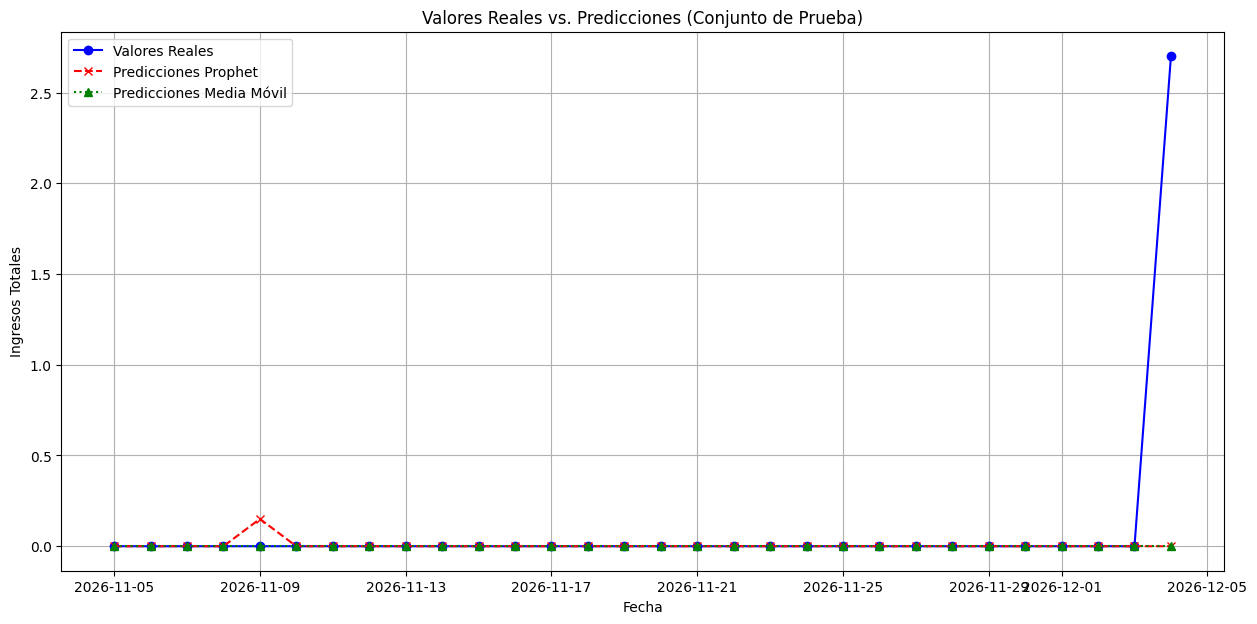

In [26]:
# Visualizar las predicciones del conjunto de prueba vs. valores reales
plt.figure(figsize=(15, 7))
plt.plot(performance_df['ds'], performance_df['y_true'], label='Valores Reales', color='blue', marker='o')
plt.plot(performance_df['ds'], performance_df['yhat'], label='Predicciones Prophet', color='red', linestyle='--', marker='x')
plt.plot(performance_df_ma['ds'], performance_df_ma['yhat_ma'], label='Predicciones Media Móvil', color='green', linestyle=':', marker='^')
plt.title('Valores Reales vs. Predicciones (Conjunto de Prueba)')
plt.xlabel('Fecha')
plt.ylabel('Ingresos Totales')
plt.legend()
plt.grid(True)
plt.show()